#Get token

In [1]:
from google.colab import userdata
token = userdata.get('Cataract')

#Randomly select 15 videos from part001 based on the data in ZipContentsReport.csv

In [3]:
import os
import random
import pandas as pd

csv_path = "/content/ZipContentsReport.csv"
df = pd.read_csv(csv_path)

VIDEO_COL = "InternalFileName"
ZIP_COL = "ZipFileName"


part1_df = df[df[ZIP_COL] == "videos_part001.zip"].copy()
part1_videos = part1_df[VIDEO_COL].dropna().astype(str).unique().tolist()

print("Total videos in part001:", len(part1_videos))

SEED = 4042
K = 15
rng = random.Random(SEED)
selected_15 = rng.sample(part1_videos, K)

print("\nSelected 15 videos:")
for v in selected_15:
    print(v)


Total videos in part001: 52

Selected 15 videos:
TR_0037_S1_P03.mp4
TR_0003_S1_P03.mp4
TR_0033_S1_P03.mp4
TR_0045_S1_P03.mp4
TR_0052_S1_P03.mp4
TR_0042_S1_P03.mp4
TR_0046_S1_P03.mp4
TR_0012_S1_P03.mp4
TR_0011_S1_P03.mp4
TR_0001_S1_P03.mp4
TR_0048_S1_P03.mp4
TR_0027_S1_P03.mp4
TR_0013_S1_P03.mp4
TR_0005_S1_P03.mp4
TR_0018_S1_P03.mp4


In [4]:
selected_ann_zips = [os.path.splitext(v)[0] + ".zip" for v in selected_15]

print("Selected annotation zips:")
for z in selected_ann_zips:
    print(z)


Selected annotation zips:
TR_0037_S1_P03.zip
TR_0003_S1_P03.zip
TR_0033_S1_P03.zip
TR_0045_S1_P03.zip
TR_0052_S1_P03.zip
TR_0042_S1_P03.zip
TR_0046_S1_P03.zip
TR_0012_S1_P03.zip
TR_0011_S1_P03.zip
TR_0001_S1_P03.zip
TR_0048_S1_P03.zip
TR_0027_S1_P03.zip
TR_0013_S1_P03.zip
TR_0005_S1_P03.zip
TR_0018_S1_P03.zip


#Downloading data from huggingface

In [5]:
import os
from huggingface_hub import hf_hub_download

HF_TOKEN = token



repo_id = "mjahmadi/Cataract-LMM"
repo_type = "dataset"

local_root = "/content/Cataract-LMM"
os.makedirs(local_root, exist_ok=True)

downloaded_paths = []

print("Starting download process using HF Token...")

for ann_zip in selected_ann_zips:
    remote_path = f"3_Object_Tracking/annotations/{ann_zip}"

    try:

        local_path = hf_hub_download(
            repo_id=repo_id,
            repo_type=repo_type,
            filename=remote_path,
            local_dir=local_root,
            token=HF_TOKEN
        )
        downloaded_paths.append(local_path)
        print("Successfully downloaded:", ann_zip)
    except Exception as e:
        print("Failed to download:", ann_zip, "| Error:", e)

print(f"\nTotal successfully downloaded: {len(downloaded_paths)}/{len(selected_ann_zips)}")


Starting download process using HF Token...


3_Object_Tracking/annotations/TR_0037_S1(…):   0%|          | 0.00/577M [00:00<?, ?B/s]

Successfully downloaded: TR_0037_S1_P03.zip


3_Object_Tracking/annotations/TR_0003_S1(…):   0%|          | 0.00/870M [00:00<?, ?B/s]

Successfully downloaded: TR_0003_S1_P03.zip


...

Successfully downloaded: TR_0013_S1_P03.zip


3_Object_Tracking/annotations/TR_0005_S1(…):   0%|          | 0.00/140M [00:00<?, ?B/s]

Successfully downloaded: TR_0005_S1_P03.zip


3_Object_Tracking/annotations/TR_0018_S1(…):   0%|          | 0.00/872M [00:00<?, ?B/s]

Successfully downloaded: TR_0018_S1_P03.zip

Total successfully downloaded: 15/15


#Inspecting the structure of files inside the zip folder

In [6]:
import zipfile
import os
import glob


zip_files = glob.glob("/content/Cataract-LMM/**/*.zip", recursive=True)

if not zip_files:
    print("هیچ فایل زیپی در مسیر مشخص شده پیدا نشد. لطفاً مسیر محلی را بررسی کنید.")
else:

    sample_zip = zip_files[0]
    print(f"Checking structure of: {os.path.basename(sample_zip)}")

    with zipfile.ZipFile(sample_zip, 'r') as z:
        file_list = z.namelist()
        print(f"Total files inside this ZIP: {len(file_list)}")


        print("\nFirst 20 files/paths inside the ZIP:")
        for name in file_list[:20]:
            print(" -", name)


        keywords = ['pupil', 'cornea', 'mask', 'tip', 'tool', 'json', 'keypoint', 'coordinate']
        found_keywords = {kw: [] for kw in keywords}

        for name in file_list:
            name_lower = name.lower()
            for kw in keywords:
                if kw in name_lower:
                    found_keywords[kw].append(name)

        print("\n--- Keyword search inside ZIP structure ---")
        for kw, matches in found_keywords.items():
            print(f"Keyword '{kw}': Found {len(matches)} matches (showing up to 3):")
            for m in matches[:3]:
                print("   ->", m)


Checking structure of: TR_0018_S1_P03.zip
Total files inside this ZIP: 9242

First 20 files/paths inside the ZIP:
 - TR_0018_S1_P03/
 - TR_0018_S1_P03/annotation.csv
 - TR_0018_S1_P03/annotation.json
 - TR_0018_S1_P03/annotation_full.json
 - TR_0018_S1_P03/TR_0018_S1_P03_000001.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000002.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000003.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000004.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000005.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000006.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000007.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000008.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000009.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000010.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000011.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000012.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000013.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000014.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000015.jpg
 - TR_0018_S1_P03/TR_0018_S1_P03_000016.jpg

--- Keyword search inside ZIP structure ---
Keyword 'pup

#Analyzing the structure of CSV and JSON files

In [ ]:
import zipfile
import json
import pandas as pd
import glob
import io


zip_files = glob.glob("/content/Cataract-LMM/**/*.zip", recursive=True)

if zip_files:
    sample_zip = zip_files[0]
    print(f"Reading metadata from: {sample_zip}\n")

    with zipfile.ZipFile(sample_zip, 'r') as z:

        csv_path = [f for f in z.namelist() if f.endswith('annotation.csv')][0]
        json_path = [f for f in z.namelist() if f.endswith('annotation_full.json')][0]


        print("--- [annotation.csv] preview ---")
        with z.open(csv_path) as f:
            df_ann = pd.read_csv(f)
            print("Columns available:", df_ann.columns.tolist())
            print("\nFirst 5 rows:")
            print(df_ann.head(5))


        print("\n--- [annotation_full.json] preview ---")
        with z.open(json_path) as f:
            data = json.load(f)

            if isinstance(data, dict):
                print("Root level keys:", list(data.keys()))

                first_key = list(data.keys())[0]
                print(f"\nValue structure for key '{first_key}':")

                print(json.dumps(data[first_key], indent=2)[:1000])
            elif isinstance(data, list):
                print(f"JSON is a list of length: {len(data)}")
                print("\nFirst element structure:")
                print(json.dumps(data[0], indent=2)[:1000])
else:
    print("No ZIP files found.")


Reading metadata from: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0001_S1_P03.zip

--- [annotation.csv] preview ---
Columns available: ['frame_number', 'filename', 'cystotome_bbox', 'cystotome_tip', 'cystotome_seg', 'cystotome_vel_abs', 'cystotome_acc_abs', 'cystotome_jerk_abs', 'cystotome_pos_rel', 'cystotome_vel_rel', 'cystotome_acc_rel', 'cystotome_jerk_rel', 'cornea_bbox', 'cornea_center', 'cornea_seg', 'pupil_bbox', 'pupil_center', 'pupil_seg']

First 5 rows:
   frame_number                   filename       cystotome_bbox  \
0             1  TR_0001_S1_P03_000001.jpg  [340, 204, 221, 51]   
1             2  TR_0001_S1_P03_000002.jpg  [336, 204, 225, 50]   
2             3  TR_0001_S1_P03_000003.jpg  [336, 204, 218, 50]   
3             4  TR_0001_S1_P03_000004.jpg  [336, 204, 220, 51]   
4             5  TR_0001_S1_P03_000005.jpg  [336, 208, 220, 46]   

      cystotome_tip                                      cystotome_seg  \
0               NaN  [[340, 204, 340, 214,

#Calculating the number of frames for cornea, pupil and tools per video

In [ ]:
import os
import zipfile
import glob
import pandas as pd
import ast

local_root = "/content/Cataract-LMM"
zip_files = glob.glob(f"{local_root}/**/*.zip", recursive=True)

stats = []

print("Analyzing downloaded annotation ZIPs for Bounding Boxes...\n")

for zip_path in zip_files:
    zip_name = os.path.basename(zip_path)
    video_id = os.path.splitext(zip_name)[0]

    with zipfile.ZipFile(zip_path, 'r') as zf:
        csv_files = [f for f in zf.namelist() if f.endswith('annotation.csv')]
        if not csv_files:
            continue

        csv_path = csv_files[0]
        with zf.open(csv_path) as f:
            df = pd.read_csv(f)
            total_frames = len(df)


            def is_valid_entry(val):
                if pd.isna(val):
                    return False
                try:

                    parsed = ast.literal_eval(str(val))
                    return isinstance(parsed, list) and len(parsed) > 0
                except:
                    return False

            valid_tips = df['cystotome_tip'].apply(is_valid_entry).sum()
            valid_cornea_bbox = df['cornea_bbox'].apply(is_valid_entry).sum()
            valid_pupil_bbox = df['pupil_bbox'].apply(is_valid_entry).sum()

            stats.append({
                "Video ID": video_id,
                "Total Frames": total_frames,
                "Frames with Tool Tip": valid_tips,
                "Frames with Cornea BBox": valid_cornea_bbox,
                "Frames with Pupil BBox": valid_pupil_bbox
            })

df_stats = pd.DataFrame(stats)
print("--- BBOX AND TIP COUNT REPORT ---")
print(df_stats.to_string(index=False))

df_stats.to_csv("/content/bbox_statistics_report.csv", index=False)


Analyzing downloaded annotation ZIPs for Bounding Boxes...

--- BBOX AND TIP COUNT REPORT ---
      Video ID  Total Frames  Frames with Tool Tip  Frames with Cornea BBox  Frames with Pupil BBox
TR_0001_S1_P03          2046                  1641                     2046                    2046
TR_0013_S1_P03          2912                  2571                     2912                    2912
TR_0012_S1_P03          4242                  4062                     4242                    4242
TR_0045_S1_P03          1680                  1599                     1680                    1680
TR_0005_S1_P03          3165                  3165                     3165                    3165
TR_0052_S1_P03          1035                   983                     1035                    1035
TR_0048_S1_P03          1351                  1314                     1351                    1351
TR_0042_S1_P03          2849                  2842                     2849                    2849
TR_000

#Plotting the frame counts for cornea, pupil and tools per video

          video_id  total_frames  pupil_bbox  cornea_bbox  cystotome_tip
0   TR_0001_S1_P03          2046        2046         2046           1641
1   TR_0003_S1_P03          9421        9421         9421           4933
2   TR_0005_S1_P03          3165        3165         3165           3165
3   TR_0011_S1_P03          4196        4196         4196           4022
4   TR_0012_S1_P03          4242        4242         4242           4062
5   TR_0013_S1_P03          2912        2912         2912           2571
6   TR_0018_S1_P03          9238        9238         9238           5422
7   TR_0027_S1_P03          2638        2638         2638           2638
8   TR_0033_S1_P03          2906        2906         2906           2906
9   TR_0037_S1_P03          4592        4592         4592           4499
10  TR_0042_S1_P03          2849        2849         2849           2842
11  TR_0045_S1_P03          1680        1680         1680           1599
12  TR_0046_S1_P03          3317        3317       

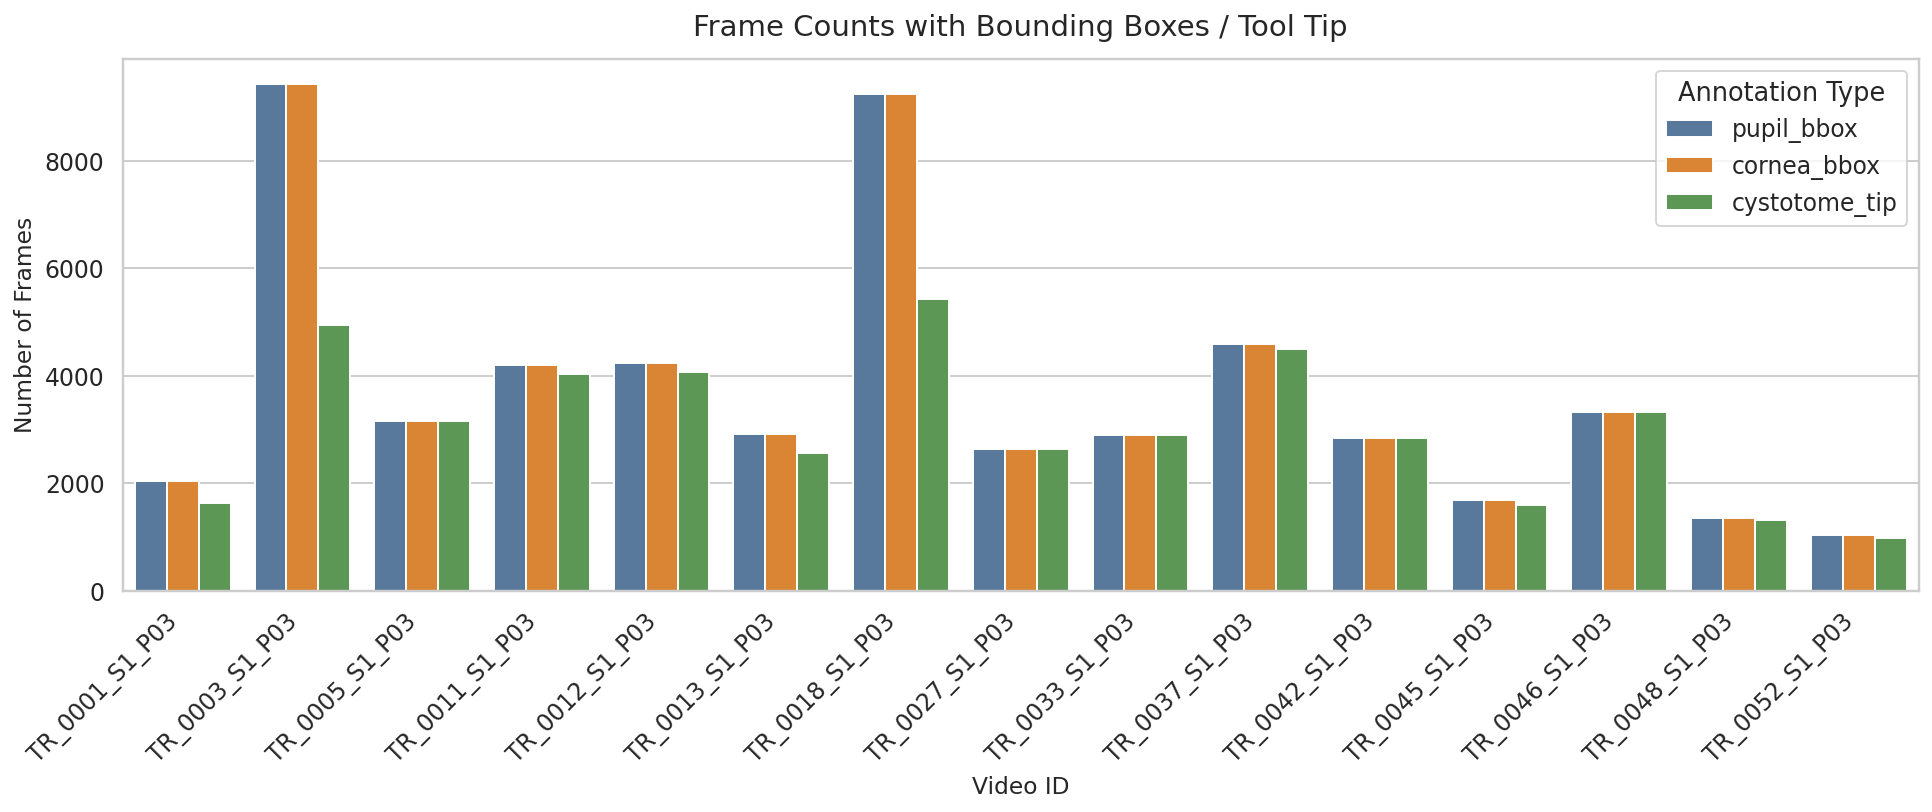

In [ ]:
import os
import zipfile
import glob
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# تنظیمات ظاهری نمودار
# -----------------------------
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 140

# اگر فونت فارسی در سیستم داری، می‌توانی این را هم تنظیم کنی:
# plt.rcParams["font.family"] = "Tahoma"

# -----------------------------
# مسیر پوشه‌ای که zipها داخلش هستند
# -----------------------------
local_root = "/content/Cataract-LMM"
zip_files = sorted(glob.glob(f"{local_root}/**/*.zip", recursive=True))

# -----------------------------
# تابع بررسی معتبر بودن مقدار
# -----------------------------
def is_valid_entry(val):
    if pd.isna(val):
        return False
    try:
        parsed = ast.literal_eval(str(val))
        return parsed is not None and parsed != [] and parsed != ""
    except:
        return False

# -----------------------------
# جمع‌آوری آمار
# -----------------------------
rows = []

for zip_path in zip_files:
    zip_name = os.path.basename(zip_path)
    video_id = os.path.splitext(zip_name)[0]

    with zipfile.ZipFile(zip_path, "r") as zf:
        csv_files = [f for f in zf.namelist() if f.endswith("annotation.csv")]
        if not csv_files:
            continue

        with zf.open(csv_files[0]) as f:
            df = pd.read_csv(f)

            rows.append({
                "video_id": video_id,
                "total_frames": len(df),
                "pupil_bbox": df["pupil_bbox"].apply(is_valid_entry).sum() if "pupil_bbox" in df.columns else 0,
                "cornea_bbox": df["cornea_bbox"].apply(is_valid_entry).sum() if "cornea_bbox" in df.columns else 0,
                "cystotome_tip": df["cystotome_tip"].apply(is_valid_entry).sum() if "cystotome_tip" in df.columns else 0
            })

stats_df = pd.DataFrame(rows)

# -----------------------------
# نمایش جدول
# -----------------------------
print(stats_df)

# -----------------------------
# نمودار ستونی
# -----------------------------
plot_df = stats_df.melt(
    id_vars="video_id",
    value_vars=["pupil_bbox", "cornea_bbox", "cystotome_tip"],
    var_name="annotation_type",
    value_name="frame_count"
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=plot_df,
    x="video_id",
    y="frame_count",
    hue="annotation_type",
    palette=["#4C78A8", "#F58518", "#54A24B"]
)

ax.set_title("Frame Counts with Bounding Boxes / Tool Tip", fontsize=15, pad=12)
ax.set_xlabel("Video ID", fontsize=12)
ax.set_ylabel("Number of Frames", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Annotation Type", frameon=True)
plt.tight_layout()
plt.show()


#Calculating the total frame counts for cornea, pupil and tools across all videos

In [ ]:
import os
import zipfile
import glob
import pandas as pd
import ast

# مسیر پوشه‌ای که zipها داخلش هستند
local_root = "/content/Cataract-LMM"
zip_files = sorted(glob.glob(f"{local_root}/**/*.zip", recursive=True))

def is_valid_entry(val):
    """بررسی می‌کند آیا مقدار، annotation معتبر دارد یا نه."""
    if pd.isna(val):
        return False
    try:
        parsed = ast.literal_eval(str(val))
        return parsed is not None and parsed != [] and parsed != ""
    except:
        return False

total_cornea = 0
total_pupil = 0
total_tool = 0
total_frames = 0

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as zf:
        csv_files = [f for f in zf.namelist() if f.endswith("annotation.csv")]
        if not csv_files:
            continue

        with zf.open(csv_files[0]) as f:
            df = pd.read_csv(f)
            total_frames += len(df)

            if "cornea_bbox" in df.columns:
                total_cornea += df["cornea_bbox"].apply(is_valid_entry).sum()

            if "pupil_bbox" in df.columns:
                total_pupil += df["pupil_bbox"].apply(is_valid_entry).sum()

            if "cystotome_tip" in df.columns:
                total_tool += df["cystotome_tip"].apply(is_valid_entry).sum()

print("=== Total Annotation Counts Across All ZIPs ===")
print(f"Total frames: {total_frames}")
print(f"Total cornea_bbox frames: {total_cornea}")
print(f"Total pupil_bbox frames: {total_pupil}")
print(f"Total cystotome_tip frames: {total_tool}")


=== Total Annotation Counts Across All ZIPs ===
Total frames: 55588
Total cornea_bbox frames: 55588
Total pupil_bbox frames: 55588
Total cystotome_tip frames: 45914


#Extracting and saving annotation archives and their corresponding video frames

In [7]:
import os
import glob
import zipfile

src_root = "/content/Cataract-LMM/3_Object_Tracking/annotations"
dst_root = "/content/Cataract-LMM/3_Object_Tracking/annotations_extracted"

os.makedirs(dst_root, exist_ok=True)

zip_paths = sorted(glob.glob(os.path.join(src_root, "**", "*.zip"), recursive=True))

print(f"Found {len(zip_paths)} zip files.\n")

for i, zip_path in enumerate(zip_paths, 1):
    zip_name = os.path.splitext(os.path.basename(zip_path))[0]
    extract_path = os.path.join(dst_root, zip_name)

    os.makedirs(extract_path, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_path)
        print(f"[{i}/{len(zip_paths)}] Extracted: {zip_path}")
        print(f"    -> {extract_path}")
    except Exception as e:
        print(f"[{i}/{len(zip_paths)}] FAILED: {zip_path}")
        print(f"    Error: {e}")

print("\nDone.")


Found 15 zip files.

[1/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0001_S1_P03.zip
    -> /content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0001_S1_P03
[2/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0003_S1_P03.zip
    -> /content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0003_S1_P03
[3/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0005_S1_P03.zip
    -> /content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0005_S1_P03
[4/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0011_S1_P03.zip
    -> /content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0011_S1_P03
[5/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0012_S1_P03.zip
    -> /content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0012_S1_P03
[6/15] Extracted: /content/Cataract-LMM/3_Object_Tracking/annotations/TR_0013_S1_P03.zip
    -> /content/Cataract-

#Collecting all CSV and JSON files for every video

In [8]:
import os
import glob
import zipfile

src_root = "/content/Cataract-LMM/3_Object_Tracking/annotations"
dst_root = "/content/Cataract-LMM/3_Object_Tracking/collected_ann_files"

csv_dir = os.path.join(dst_root, "csvs")
json_dir = os.path.join(dst_root, "jsons")

os.makedirs(csv_dir, exist_ok=True)
os.makedirs(json_dir, exist_ok=True)

zip_paths = sorted(glob.glob(os.path.join(src_root, "**", "*.zip"), recursive=True))

for i, zip_path in enumerate(zip_paths, 1):
    zip_name = os.path.splitext(os.path.basename(zip_path))[0]

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            for member in zf.namelist():
                if member.endswith("/"):
                    continue

                lower = member.lower()
                if not (lower.endswith(".csv") or lower.endswith(".json")):
                    continue

                data = zf.read(member)
                base = os.path.basename(member)

                # برای جلوگیری از overwrite
                out_name = f"{zip_name}__{base}"

                if lower.endswith(".csv"):
                    out_path = os.path.join(csv_dir, out_name)
                else:
                    out_path = os.path.join(json_dir, out_name)

                with open(out_path, "wb") as f:
                    f.write(data)

        print(f"[{i}/{len(zip_paths)}] done: {zip_name}")

    except Exception as e:
        print(f"[{i}/{len(zip_paths)}] FAILED: {zip_name} -> {e}")

print("Finished.")


[1/15] done: TR_0001_S1_P03
[2/15] done: TR_0003_S1_P03
[3/15] done: TR_0005_S1_P03
[4/15] done: TR_0011_S1_P03
[5/15] done: TR_0012_S1_P03
[6/15] done: TR_0013_S1_P03
[7/15] done: TR_0018_S1_P03
[8/15] done: TR_0027_S1_P03
[9/15] done: TR_0033_S1_P03
[10/15] done: TR_0037_S1_P03
[11/15] done: TR_0042_S1_P03
[12/15] done: TR_0045_S1_P03
[13/15] done: TR_0046_S1_P03
[14/15] done: TR_0048_S1_P03
[15/15] done: TR_0052_S1_P03
Finished.


#Overlaying bounding boxes and end effector markers on 5 frames

In [ ]:
import json
import os
import cv2
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as patches


json_path = "/content/Cataract-LMM/3_Object_Tracking/collected_ann_files/jsons/TR_0001_S1_P03__annotation_full.json"
frames_root = "/content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0001_S1_P03/TR_0001_S1_P03"
csv_path = "/content/Cataract-LMM/3_Object_Tracking/collected_ann_files/csvs/TR_0001_S1_P03__annotation.csv"


with open(json_path, "r") as f:
    data = json.load(f)

cat_map = {cat["id"]: cat["name"] for cat in data["categories"]}
video_sample = data["videos"][0]
num_frames = len(video_sample["file_names"])


df_csv = pd.read_csv(csv_path)


tip_data = {}
for _, row in df_csv.iterrows():
    f_num = int(row['frame_number'])
    tip_str = row['cystotome_tip']


    try:
        if pd.notna(tip_str) and tip_str != "None":
            tip_coords = ast.literal_eval(tip_str)
            if len(tip_coords) == 2:
                tip_data[f_num] = tip_coords
    except:
        continue


frame_annotations = {i: [] for i in range(num_frames)}

for ann in data["annotations"]:
    cat_name = cat_map.get(ann["category_id"], "Unknown")
    bboxes = ann.get("bboxes", [])

    for frame_idx in range(min(num_frames, len(bboxes))):
        bbox = bboxes[frame_idx]
        if bbox is None:
            continue


        ee_pos = None


        if cat_name in ["Cystotome", "Cap-Cystotome"]:

            ee_pos = tip_data.get(frame_idx) or tip_data.get(frame_idx + 1)

        frame_annotations[frame_idx].append({
            "category_name": cat_name,
            "bbox": bbox,
            "end_effector": ee_pos
        })



def draw_bbox(ax, bbox, color, label):
    if bbox is None or len(bbox) != 4: return
    x, y, w, h = bbox
    rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x, max(0, y - 8), label, color='black', fontsize=9, weight='bold',
            bbox=dict(facecolor=color, alpha=0.8, pad=2))

def draw_end_effector(ax, ee, color="red"):
    if ee is None: return
    x, y = ee[0], ee[1]

    ax.scatter([x], [y], marker='x', s=150, c=color, linewidths=3, zorder=10)


def visualize_frames(start=0, n=5):
    end = min(start + n, num_frames)
    indices = list(range(start, end))

    fig, axes = plt.subplots(1, len(indices), figsize=(6 * len(indices), 6))
    if len(indices) == 1: axes = [axes]

    for ax, frame_idx in zip(axes, indices):
        frame_name = video_sample["file_names"][frame_idx]
        img_path = os.path.join(frames_root, os.path.basename(frame_name))

        if not os.path.exists(img_path):
            ax.text(0.5, 0.5, f"Missing:\n{frame_name}", ha="center")
            ax.axis("off")
            continue

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        anns = frame_annotations.get(frame_idx, [])
        for ann in anns:
            cat_name = ann["category_name"]

            color = {
                "Cornea": "#00FFFF",
                "Pupil": "#FF00FF",
                "Cystotome": "#00FF00",
                "Cap-Cystotome": "#FFFF00"
            }.get(cat_name, "#FF4500")

            draw_bbox(ax, ann["bbox"], color, cat_name)


            if cat_name in ["Cystotome", "Cap-Cystotome"] and ann["end_effector"] is not None:
                draw_end_effector(ax, ann["end_effector"], color="#FF0000")

        ax.set_title(f"Frame {frame_idx}", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_frames(start=0, n=5)


Output hidden; open in https://colab.research.google.com to view.

In [9]:
import json
import os
import cv2
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from scipy.signal import savgol_filter


try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    output_dir = "/content/drive/MyDrive/Surgical_Robotics_Outputs"
    os.makedirs(output_dir, exist_ok=True)
    output_video_path = os.path.join(output_dir, "Surgical_Kinematic_Dashboard_33_v1.mp4")
except:
    output_dir = "."
    output_video_path = "Surgical_Kinematic_Dashboard_33_v1.mp4"

json_path = "/content/Cataract-LMM/3_Object_Tracking/collected_ann_files/jsons/TR_0033_S1_P03__annotation_full.json"
frames_root = "/content/Cataract-LMM/3_Object_Tracking/annotations_extracted/TR_0033_S1_P03/TR_0033_S1_P03"
csv_path = "/content/Cataract-LMM/3_Object_Tracking/collected_ann_files/csvs/TR_0033_S1_P03__annotation.csv"


SAFE_RADIUS_RATIO = 0.75
JERK_THRESHOLD = 5.0


BLINK_FREQ = 60

FPS = 30.0
EPSILON = 1e-8


NEON_CYAN = (255, 255, 0)
NEON_MAGENTA = (255, 0, 255)
DEEP_GREEN = (0, 200, 0)
WARNING_ORANGE = (0, 140, 255)
CRITICAL_RED = (0, 0, 255)
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)

Mounted at /content/drive


#Surgical Robotic Kinematic Analysis and Safety Monitoring Framework

Starting rendering: 2906 frames...
Video saved at: /content/drive/MyDrive/Surgical_Robotics_Outputs/Surgical_Kinematic_Dashboard_33_v1.mp4


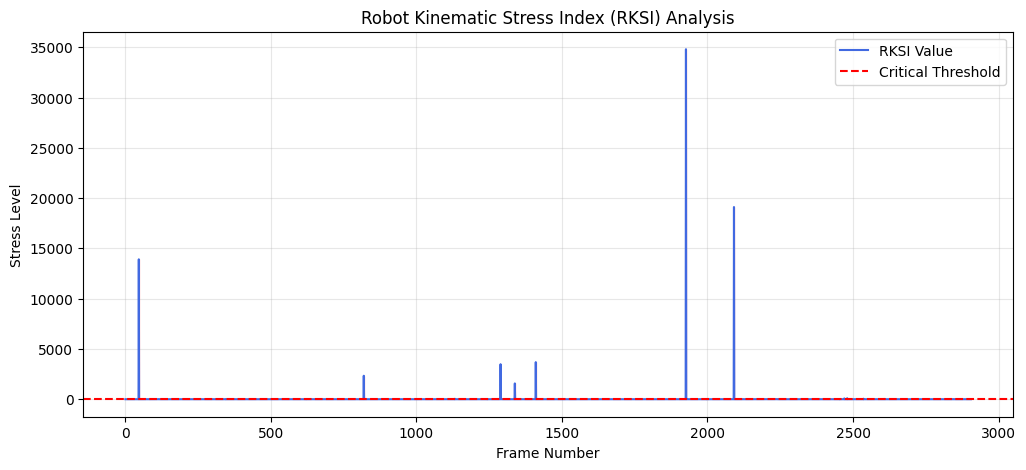

Analysis plot saved at: /content/drive/MyDrive/Surgical_Robotics_Outputs/RKSI_Analysis_Plot.png


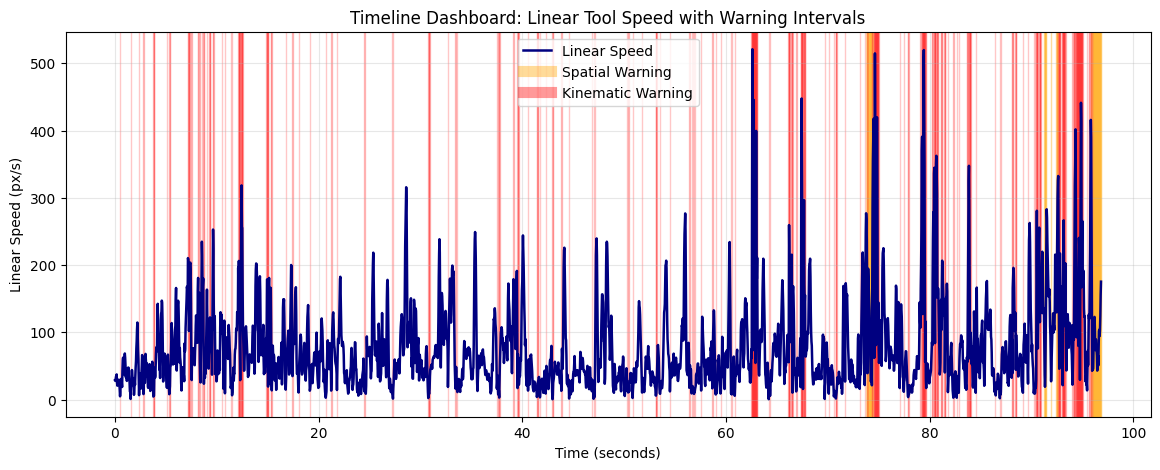

Timeline dashboard saved at: /content/drive/MyDrive/Surgical_Robotics_Outputs/Timeline_Dashboard.png


In [10]:
def draw_bold_label(img, text, pos, color, scale=0.4, thickness=1):

    cv2.putText(
        img,
        text,
        (pos[0] + 1, pos[1] + 1),
        cv2.FONT_HERSHEY_DUPLEX,
        scale,
        BLACK,
        thickness + 1,
        cv2.LINE_AA
    )
    cv2.putText(
        img,
        text,
        pos,
        cv2.FONT_HERSHEY_DUPLEX,
        scale,
        color,
        thickness,
        cv2.LINE_AA
    )


with open(json_path, "r") as f:
    data = json.load(f)

df_csv = pd.read_csv(csv_path)
video_info = data["videos"][0]
num_frames = len(video_info["file_names"])
width, height = video_info["width"], video_info["height"]


raw_coords = np.full((num_frames, 2), np.nan)
for _, row in df_csv.iterrows():
    f_num = int(row["frame_number"])
    idx = f_num - 1 if f_num >= 1 else f_num
    if 0 <= idx < num_frames:
        tip = ast.literal_eval(row["cystotome_tip"]) if pd.notna(row["cystotome_tip"]) and row["cystotome_tip"] != "None" else None
        if tip:
            raw_coords[idx] = [tip[0], tip[1]]


df_coords = pd.DataFrame(raw_coords, columns=["x", "y"]).interpolate().ffill().bfill()
smooth_x = savgol_filter(df_coords["x"], 11, 3)
smooth_y = savgol_filter(df_coords["y"], 11, 3)


vx, vy = np.gradient(smooth_x), np.gradient(smooth_y)
ax, ay = np.gradient(vx), np.gradient(vy)
jx, jy = np.gradient(ax), np.gradient(ay)

speed = np.sqrt(vx**2 + vy**2)
acc_mag = np.sqrt(ax**2 + ay**2)
jerk_mag = np.sqrt(jx**2 + jy**2)
curvature = np.abs(vx * ay - vy * ax) / (speed**3 + EPSILON)


cat_map = {cat["id"]: cat["name"] for cat in data["categories"]}
frames_data = {i: {"cornea": None, "pupil": None, "tools": []} for i in range(num_frames)}

for ann in data["annotations"]:
    cat_name = cat_map.get(ann["category_id"])
    bboxes = ann.get("bboxes", [])
    for f_idx, box in enumerate(bboxes):
        if f_idx < num_frames and box:
            if cat_name == "Cornea":
                frames_data[f_idx]["cornea"] = box
            elif cat_name == "Pupil":
                frames_data[f_idx]["pupil"] = box
            elif cat_name in ["Cystotome", "Cap-Cystotome"]:
                frames_data[f_idx]["tools"].append({"name": cat_name, "bbox": box})


boundary_dist = np.zeros(num_frames)
for i in range(num_frames):
    cornea = frames_data[i]["cornea"]
    if cornea:
        cx, cy, cw, ch = cornea
        center_x = cx + cw / 2
        center_y = cy + ch / 2

        cornea_radius = min(cw, ch) / 2
        safe_radius = cornea_radius * SAFE_RADIUS_RATIO

        dx = smooth_x[i] - center_x
        dy = smooth_y[i] - center_y
        dist = np.sqrt(dx**2 + dy**2)

        boundary_dist[i] = max(dist - safe_radius, 0.0)


def norm_p95(arr):
    return arr / (np.nanpercentile(arr, 95) + EPSILON)

j_n = norm_p95(jerk_mag)
a_n = norm_p95(acc_mag)
c_n = norm_p95(curvature)
b_risk_n = norm_p95(1.0 / (boundary_dist + EPSILON))


RKSI = (
    0.35 * j_n**2 +
    0.25 * a_n**2 +
    0.20 * c_n**2 +
    0.20 * b_risk_n**2
)
RKSI_THRESHOLD = np.nanpercentile(RKSI, 90)


is_near_edge_arr = np.zeros(num_frames, dtype=bool)
is_critical_arr = np.zeros(num_frames, dtype=bool)

for f_idx in range(num_frames):
    cornea = frames_data[f_idx]["cornea"]
    ee_pos = (smooth_x[f_idx], smooth_y[f_idx])

    is_near_edge = False
    if cornea:
        cx, cy, cw, ch = cornea
        center_x = cx + cw / 2
        center_y = cy + ch / 2

        cornea_radius = min(cw, ch) / 2
        safe_radius = cornea_radius * SAFE_RADIUS_RATIO

        dx = ee_pos[0] - center_x
        dy = ee_pos[1] - center_y
        dist = np.sqrt(dx**2 + dy**2)

        is_near_edge = dist > safe_radius

    is_jerk_high = jerk_mag[f_idx] > JERK_THRESHOLD
    is_rksi_high = RKSI[f_idx] > RKSI_THRESHOLD
    is_critical = is_jerk_high or is_rksi_high

    is_near_edge_arr[f_idx] = is_near_edge
    is_critical_arr[f_idx] = is_critical


fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video_path, fourcc, FPS, (width, height))
trajectory = deque(maxlen=30)

print(f"Starting rendering: {num_frames} frames...")

for f_idx in range(num_frames):
    fname = os.path.basename(video_info["file_names"][f_idx])
    frame_path = os.path.join(frames_root, fname)
    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"Warning: could not read frame: {frame_path}")
        continue

    cornea = frames_data[f_idx]["cornea"]
    pupil = frames_data[f_idx]["pupil"]
    ee_pos = (smooth_x[f_idx], smooth_y[f_idx])

    is_near_edge = is_near_edge_arr[f_idx]
    is_critical = is_critical_arr[f_idx]

    trajectory.append((ee_pos, is_near_edge, is_critical))


    if cornea:
        x, y, w, h = [int(v) for v in cornea]
        center = (x + w // 2, y + h // 2)
        cornea_radius = int(min(w, h) / 2)
        safe_radius = int(cornea_radius * SAFE_RADIUS_RATIO)

        cv2.circle(frame, center, cornea_radius, NEON_CYAN, 2)
        draw_bold_label(frame, "Cornea", (x + 10, y + 20), NEON_CYAN, scale=0.45, thickness=1)

        cv2.circle(frame, center, safe_radius, WARNING_ORANGE, 1, cv2.LINE_AA)
        draw_bold_label(
            frame,
            "Inner Safe Limit",
            (center[0] - 45, center[1] - safe_radius - 6),
            WARNING_ORANGE,
            scale=0.32,
            thickness=1
        )

    if pupil:
        x_p, y_p, w_p, h_p = [int(v) for v in pupil]
        pupil_center = (x_p + w_p // 2, y_p + h_p // 2)
        pupil_radius = int(min(w_p, h_p) / 2)
        cv2.circle(frame, pupil_center, pupil_radius, NEON_MAGENTA, 2)
        draw_bold_label(frame, "Pupil", (x_p + 10, y_p + 20), NEON_MAGENTA, scale=0.45, thickness=1)


    for i in range(1, len(trajectory)):
        p1, d_b, d_c = trajectory[i - 1]
        p2 = trajectory[i][0]
        color = CRITICAL_RED if d_c else (WARNING_ORANGE if d_b else DEEP_GREEN)
        cv2.line(
            frame,
            (int(p1[0]), int(p1[1])),
            (int(p2[0]), int(p2[1])),
            color,
            2,
            cv2.LINE_AA
        )


    tool_color = CRITICAL_RED if is_critical else (WARNING_ORANGE if is_near_edge else DEEP_GREEN)
    for tool in frames_data[f_idx]["tools"]:
        bx, by, bw, bh = [int(v) for v in tool["bbox"]]
        cv2.rectangle(frame, (bx, by), (bx + bw, by + bh), tool_color, 2)
        draw_bold_label(frame, tool["name"], (bx + 5, by - 8), tool_color, scale=0.42, thickness=1)

    cv2.drawMarker(
        frame,
        (int(ee_pos[0]), int(ee_pos[1])),
        tool_color,
        cv2.MARKER_TILTED_CROSS,
        15,
        2
    )


    if is_critical:
        cv2.rectangle(frame, (0, 0), (width, height), CRITICAL_RED, 25)

        box_x1 = width // 2 - 360
        box_y1 = height - 105
        box_x2 = width // 2 + 360
        box_y2 = height - 35

        cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), BLACK, -1)
        cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), CRITICAL_RED, 2)

        cv2.putText(
            frame,
            "CRITICAL: Unstable Kinematics Detected",
            (width // 2 - 325, height - 60),
            cv2.FONT_HERSHEY_DUPLEX,
            0.85,
            CRITICAL_RED,
            2
        )

    if is_near_edge:
        if (f_idx // BLINK_FREQ) % 2 == 0:
            box_x1 = width - 460
            box_y1 = 25
            box_x2 = width - 20
            box_y2 = 95

            cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), BLACK, -1)
            cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), WARNING_ORANGE, 2)

            cv2.putText(
                frame,
                "WARNING: Boundary Proximity",
                (width - 435, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.78,
                WARNING_ORANGE,
                2
            )

    out.write(frame)

out.release()
print(f"Video saved at: {output_video_path}")


plt.figure(figsize=(12, 5))
plt.plot(RKSI, color="royalblue", label="RKSI Value")
plt.axhline(y=RKSI_THRESHOLD, color="red", linestyle="--", label="Critical Threshold")
plt.fill_between(
    range(num_frames),
    RKSI,
    RKSI_THRESHOLD,
    where=(RKSI > RKSI_THRESHOLD),
    color="red",
    alpha=0.3
)
plt.title("Robot Kinematic Stress Index (RKSI) Analysis")
plt.xlabel("Frame Number")
plt.ylabel("Stress Level")
plt.legend()
plt.grid(True, alpha=0.3)

plot_path = os.path.join(output_dir, "RKSI_Analysis_Plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Analysis plot saved at: {plot_path}")


time_axis = np.arange(num_frames) / FPS
linear_speed = speed * FPS

plt.figure(figsize=(14, 5))

for i in range(num_frames):
    t0 = i / FPS
    t1 = (i + 1) / FPS

    if is_critical_arr[i]:
        plt.axvspan(t0, t1, color="red", alpha=0.22)
    elif is_near_edge_arr[i]:
        plt.axvspan(t0, t1, color="orange", alpha=0.22)

plt.plot(time_axis, linear_speed, color="navy", linewidth=1.8, label="Linear Speed")
plt.plot([], [], color="orange", linewidth=8, alpha=0.4, label="Spatial Warning")
plt.plot([], [], color="red", linewidth=8, alpha=0.4, label="Kinematic Warning")

plt.title("Timeline Dashboard: Linear Tool Speed with Warning Intervals")
plt.xlabel("Time (seconds)")
plt.ylabel("Linear Speed (px/s)")
plt.legend()
plt.grid(True, alpha=0.3)

timeline_plot_path = os.path.join(output_dir, "Timeline_Dashboard.png")
plt.savefig(timeline_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Timeline dashboard saved at: {timeline_plot_path}")
